In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pathlib import Path
# Load the dataset
Project_Root = Path.cwd().parent

Data_Path = Project_Root / "Data"/"processed"/"Gurgaon_merged_v2.csv"
df = pd.read_csv(Data_Path)
df.sample(5)


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
1868,flat,mapsko casa bella,sector 82,0.86,8120.0,1059.0,Super Built up area 1430(132.85 sq.m.)Carpet a...,3,3,3,...,1056.00,NaN,NaN,1,0,0,0,0,0,120
469,flat,emaar gurgaon greens,sector 102,1.40,13690.0,1023.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,...,1022.58,NaN,NaN,0,1,0,0,0,2,67
1528,flat,ss,sector 85,2.10,7467.0,2812.0,Super Built up area 2812(261.24 sq.m.)Built Up...,4,4,3,...,2400.00,NaN,2600.0,0,0,0,0,0,2,49
3442,house,unitech uniworld resorts,sector 33,10.00,181818.0,550.0,Plot area 550(51.1 sq.m.),5,6,3,...,NaN,550.0,NaN,1,1,0,0,0,2,26
2821,flat,ss the leaf,sector 85,2.70,7754.0,3482.0,Super Built up area 3482(323.49 sq.m.),4,4,3+,...,NaN,NaN,NaN,0,0,0,0,0,2,21


In [4]:
# Fill missing values in 'built_up_area' with corresponding values from 'Plot_area'
df['built_up_area'] = df['built_up_area'].fillna(df['Plot_area'])

In [5]:
df.drop(columns = "Plot_area", inplace = True)

In [6]:
df.shape

(3961, 25)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3961 non-null   object 
 1   society              3961 non-null   object 
 2   sector               3961 non-null   object 
 3   price                3941 non-null   float64
 4   price_per_sqft       3941 non-null   float64
 5   area                 3941 non-null   float64
 6   areaWithType         3961 non-null   object 
 7   bedRoom              3961 non-null   int64  
 8   bathroom             3961 non-null   int64  
 9   balcony              3961 non-null   object 
 10  floorNum             3937 non-null   float64
 11  facing               2784 non-null   object 
 12  agePossession        3961 non-null   object 
 13  description          3961 non-null   object 
 14  rating               3511 non-null   object 
 15  super_built_up_area  1934 non-null   f

In [8]:
df.duplicated().sum()

np.int64(4)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum() # Check of duplicates have been removed

np.int64(0)

## Univariate Analysis with Property type

<Axes: title={'center': 'Property Type Distribution'}, xlabel='property_type'>

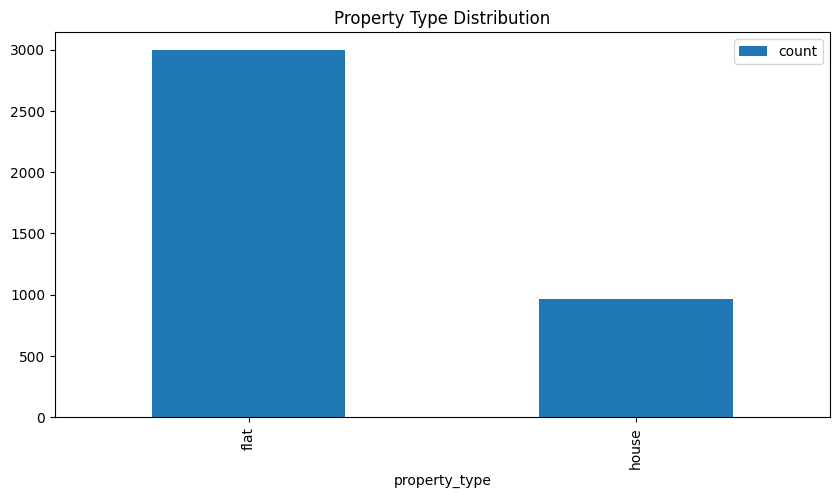

In [11]:
df.property_type.value_counts().plot(kind = 'bar', figsize = (10,5), title = "Property Type Distribution", legend = True, )

# Observation
The Data consists of 70 to 75 percent of the property type and remaining house.

# READ: property_type ~70-75% flats, rest houses. Imbalanced but flats dominate — most models will key off this.


# Society

In [12]:
df.sample(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
120,flat,breez global heights,sector 48,0.4,6420.0,623.0,Super Built up area 623(57.88 sq.m.)Carpet are...,2,2,1,...,623.0,599.0,NaN,0,0,0,0,0,2,49


In [13]:
df.society.value_counts().shape

(724,)

In [14]:
df.society.value_counts()

society
independent                             570
tulip violet                             75
ss the leaf                              74
shapoorji pallonji joyville gurugram     45
dlf new town heights                     42
                                       ... 
surbhi apartment                          1
raheja vedas                              1
cghs hewo apartments                      1
ashray apartment                          1
maa bhagwati residency                    1
Name: count, Length: 724, dtype: int64

In [15]:
df[df['society'] != "independent"]['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.022143
ss the leaf                             0.043992
shapoorji pallonji joyville gurugram    0.057278
dlf new town heights                    0.069678
signature global park                   0.080602
                                          ...   
dlf the primus                          0.475347
ireo skyon                              0.479480
ats kocoon                              0.483319
puri emerald bay                        0.487157
ireo the corridors                      0.490995
Name: proportion, Length: 75, dtype: float64

In [16]:
society_counts = df.society.value_counts()

# Frequency distribution of the society column
frequency_bin = {
    'High(>50)'        : (society_counts>50).sum(),
    'Average(10 - 49)' : ((society_counts>10) & (society_counts<50)).sum(),
    'Low(2 - 9)'       : ((society_counts>2) & (society_counts<10)).sum(),
    'very Low (1)'     : (society_counts ==1).sum()
}
frequency_bin

{'High(>50)': np.int64(3),
 'Average(10 - 49)': np.int64(88),
 'Low(2 - 9)': np.int64(189),
 'very Low (1)': np.int64(324)}

In [17]:
df.society.unique().shape

(724,)

In [18]:
df.society.value_counts(normalize = True) * 100

society
independent                             14.404852
tulip violet                             1.895375
ss the leaf                              1.870104
shapoorji pallonji joyville gurugram     1.137225
dlf new town heights                     1.061410
                                          ...    
surbhi apartment                         0.025272
raheja vedas                             0.025272
cghs hewo apartments                     0.025272
ashray apartment                         0.025272
maa bhagwati residency                   0.025272
Name: proportion, Length: 724, dtype: float64

# observations
--> There are 14 percent independent societies.
--> There are 724 unique societies.
--> The top 75 societies has 50 percent of the properties.

# READ: society — 724 unique, heavy long tail. 14% independent. Top 75 societies = 50% of listings. High cardinality → bucket to top-N + 'Other'.


In [19]:
df


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,NaN,900.0,NaN,0,0,0,0,0,2,28
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,NaN,650.0,NaN,0,0,0,0,0,0,37
2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,NaN,595.0,NaN,0,0,0,0,0,2,36
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,NaN,1200.0,NaN,1,0,0,0,0,2,76
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,1345.0,NaN,NaN,1,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3956,house,dlf city phase 1,sector 26,5.50,30556.0,1800.0,Plot area 200(167.23 sq.m.),4,4,3,...,NaN,NaN,200.0,1,1,1,0,0,2,69
3957,house,dlf city plots phase 2,sector 25,4.25,31481.0,1350.0,Plot area 150(125.42 sq.m.),3,2,3,...,NaN,NaN,150.0,1,0,0,0,0,2,35
3958,house,dlf city phase 1,sector 26,4.50,33333.0,1350.0,Plot area 150(125.42 sq.m.),3,3,2,...,NaN,NaN,150.0,1,1,0,0,0,2,70
3959,house,dlf city phase 1,sector 26,3.25,33129.0,981.0,Plot area 109(91.14 sq.m.),3,3,3,...,NaN,NaN,109.0,1,0,0,0,0,2,79


## Sector

In [20]:
df.sector.value_counts().shape

(156,)

In [21]:
df.sector.isnull().sum()

np.int64(0)

<Axes: xlabel='sector'>

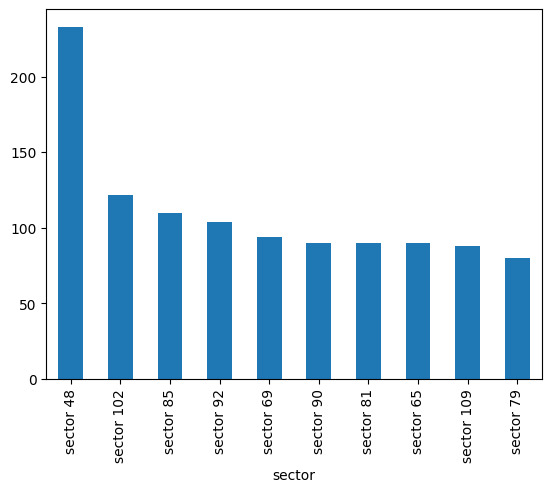

In [22]:
df.sector.value_counts().head(10).plot(kind= 'bar')

In [23]:
# Frequency distribution of the sector column
sector_counts = df.sector.value_counts()
frequency_bin_sector = {
    'Very High(>100)'        : (sector_counts>100).sum(),
    'High(50 - 100)' : ((sector_counts>=50) & (sector_counts<=100)).sum(),
    'Average(10 - 49)' : ((sector_counts>=10) & (sector_counts<=49)).sum(),
    'Low(2 - 9)'       : ((sector_counts>=2) & (sector_counts<=9)).sum(),
    'Very Low (1)'     : (sector_counts ==1).sum()
}
frequency_bin_sector

{'Very High(>100)': np.int64(4),
 'High(50 - 100)': np.int64(26),
 'Average(10 - 49)': np.int64(62),
 'Low(2 - 9)': np.int64(45),
 'Very Low (1)': np.int64(19)}

# Observation
There are 156 unique sectors.

# READ: sector — 156 unique, a few dense sectors + long tail of sparse ones. Sparse sectors give unreliable per-sector price stats.


# Price

In [24]:
df.price.isnull().sum()

np.int64(20)

In [25]:
df.price.describe()

count    3937.000000
mean        2.475827
std         2.924003
min         0.070000
25%         0.900000
50%         1.500000
75%         2.680000
max        31.500000
Name: price, dtype: float64

In [26]:
# Outlier detection using IQR method
IQR = df.price.quantile(0.75) - df.price.quantile(0.25)
lower_bound = df.price.quantile(0.25) - 1.5 * IQR
upper_bound = df.price.quantile(0.75) + 1.5 * IQR
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
Outliers = df[(df.price < lower_bound) | (df.price > upper_bound)]
print(f"Number of outliers: {(df.price < lower_bound).sum() + (df.price > upper_bound).sum()}")

Lower Bound: -1.7700000000000005, Upper Bound: 5.3500000000000005
Number of outliers: 443


In [27]:
Outliers.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
26,flat,m3m golfestate,sector 65,6.15,18331.0,3355.0,Built Up area: 3355 (311.69 sq.m.)Carpet area:...,3,4,2,...,NaN,2200.0,3355.0,0,0,0,0,0,2,0
27,flat,central park resort belgravia residences,sector 48,6.25,24300.0,2572.0,Carpet area: 2880 (267.56 sq.m.),3,5,3+,...,NaN,2880.0,NaN,0,1,0,0,0,0,49
249,flat,tulip monsella,sector 53,8.25,28000.0,2946.0,Super Built up area 2940(273.13 sq.m.),3,4,3,...,2940.0,NaN,NaN,0,1,0,0,0,1,35
281,flat,dlf the grove,sector 54,5.70,41245.0,1382.0,Built Up area: 1382 (128.39 sq.m.),3,3,3,...,NaN,NaN,1382.0,0,0,0,0,0,2,0
287,flat,m3m golfestate,sector 65,6.15,15998.0,3844.0,Carpet area: 3844 (357.12 sq.m.),3,5,3+,...,NaN,3844.0,NaN,0,1,0,0,0,1,49


In [28]:
Outliers.price.describe()

count    443.000000
mean       9.152799
std        4.046645
min        5.400000
25%        6.300000
50%        8.000000
75%       10.550000
max       31.500000
Name: price, dtype: float64

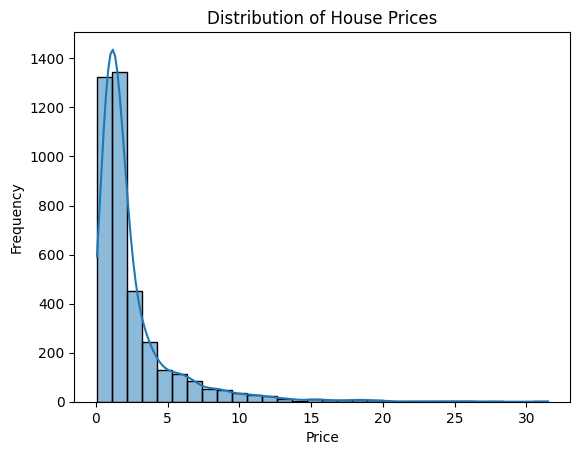

In [29]:
sns.histplot(df.price, bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


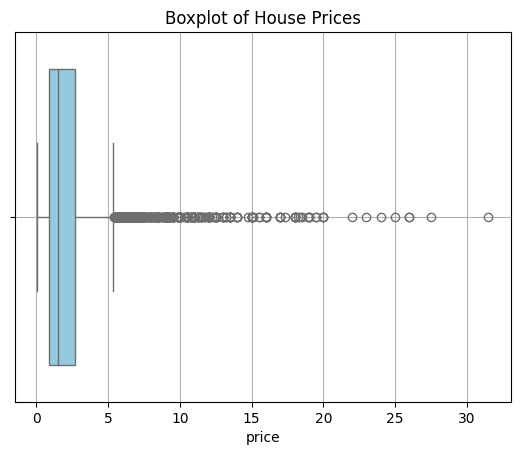

In [30]:
sns.boxplot(x=df.price, color = 'skyblue')
plt.title("Boxplot of House Prices")
plt.grid()

In [31]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

# READ: price — strongly right-skewed (skew >0, heavy kurtosis). Mean >> median. Long luxury tail; IQR flags many UPPER outliers (real premium homes, not errors).


3.328527342086744 15.461158017977702


<Axes: title={'center': 'Price Binning Distribution'}, xlabel='price'>

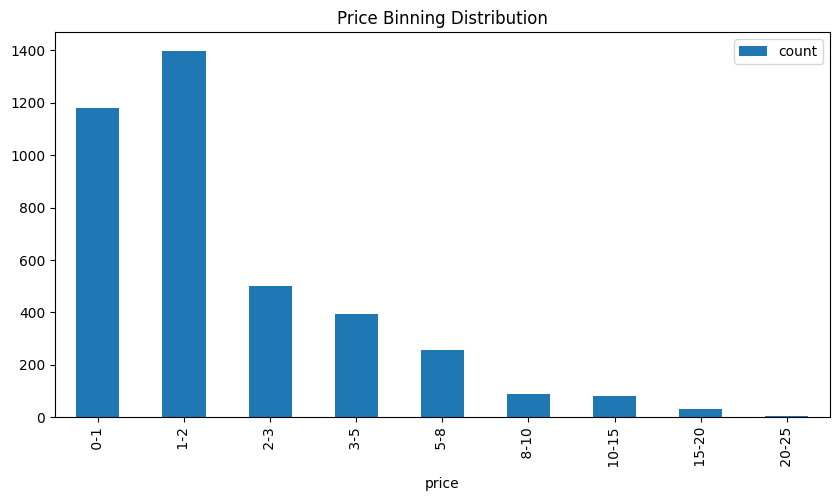

In [32]:
# Price Binning
bins = [0,1,2,3,5,8,10,15,20,25]
bins_label = [" 0-1", " 1-2", " 2-3", " 3-5", " 5-8", " 8-10", " 10-15", " 15-20", " 20-25"]
pd.cut(df['price'], bins=bins, labels=bins_label).value_counts().sort_index().plot(kind='bar', figsize=(10,5), title="Price Binning Distribution", legend=True)

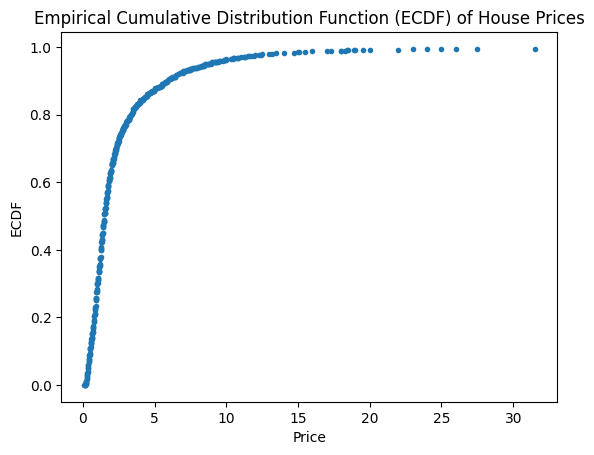

In [33]:
# ecdf plot
ecdf = df.price.value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.xlabel('Price')
plt.ylabel('ECDF')
plt.title('Empirical Cumulative Distribution Function (ECDF) of House Prices')
plt.show()

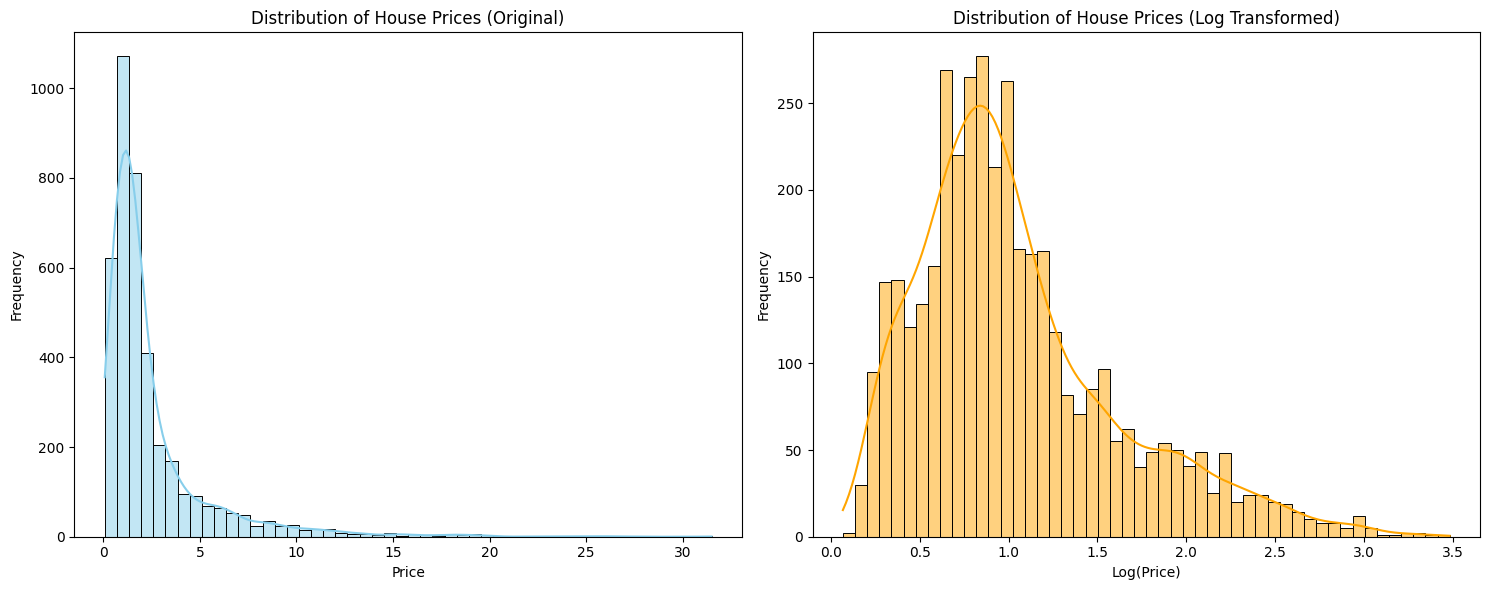

In [34]:
# Applying log transformation on the price column as to see the difference
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(df.price, kde=True, bins=50, color='skyblue')
plt.title("Distribution of House Prices (Original)")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df.price), kde=True, bins=50, color='orange')
plt.title("Distribution of House Prices (Log Transformed)")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [35]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

# READ: log(price) — skew & kurtosis collapse toward 0, near-symmetric. Model on log-price, back-transform predictions.


1.0820762044484469 1.009459567468086


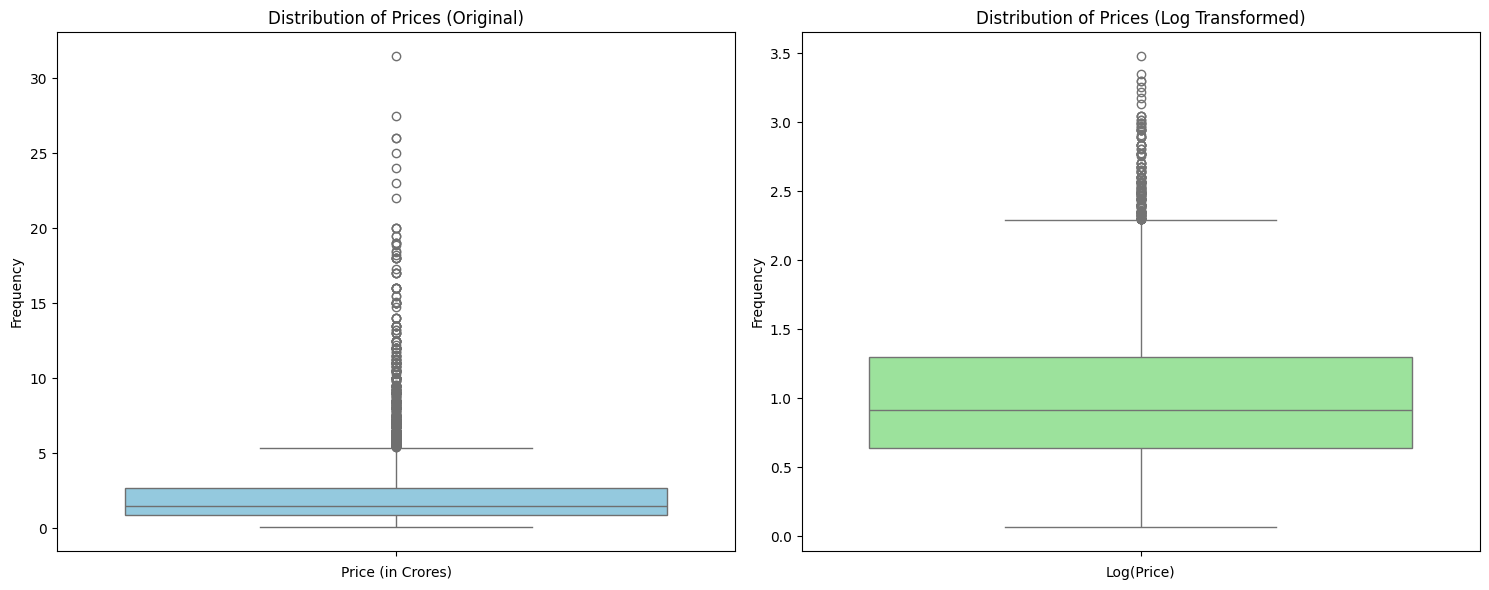

In [36]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Price_sq_feet

In [37]:
df.price_per_sqft.isnull().sum()

np.int64(20)

In [38]:
df.price_per_sqft.describe()

count      3937.000000
mean      13912.684023
std       23192.597030
min           2.000000
25%        6789.000000
50%        9000.000000
75%       13750.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

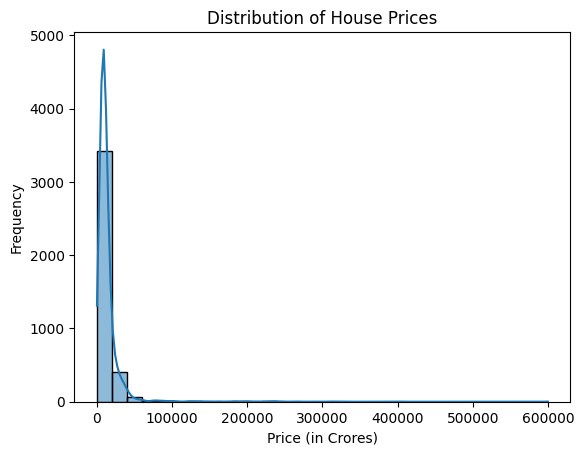

In [39]:
sns.histplot(df.price_per_sqft, bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (in Crores)")
plt.ylabel("Frequency")
plt.show()

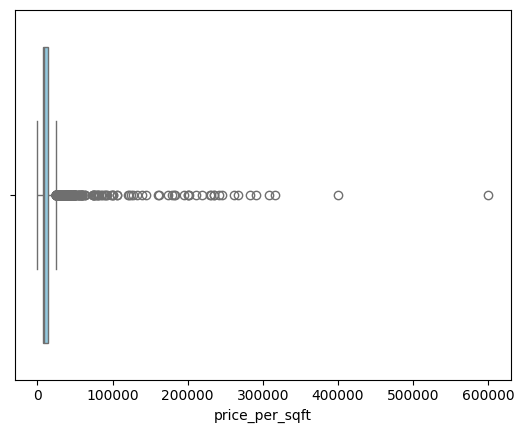

In [40]:
sns.boxplot(x=df.price_per_sqft, color = 'skyblue')
plt.show()

# READ: price_per_sqft — right-skewed. Extreme highs are likely upstream area/price errors, not true luxury. Use as a data-quality tripwire.


# Bedroom

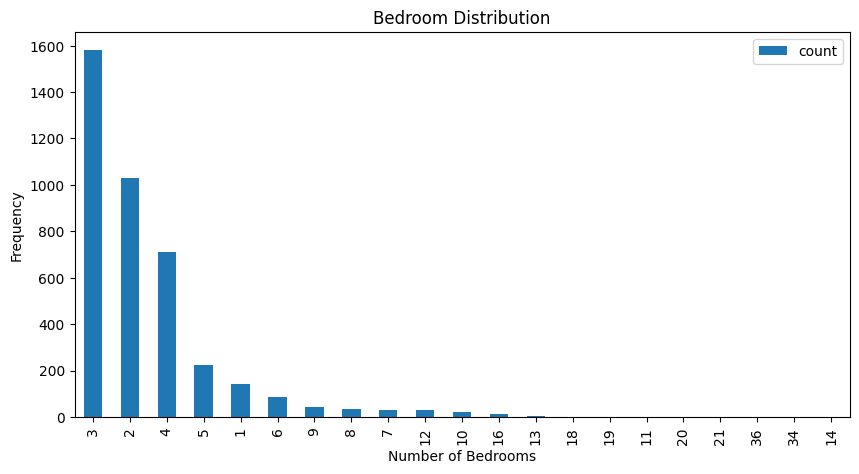

In [41]:
df.bedRoom.value_counts().plot(kind = 'bar', figsize = (10,5), title = "Bedroom Distribution", legend = True)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Frequency")
plt.show()

<Axes: title={'center': 'Bedroom Distribution'}, ylabel='proportion'>

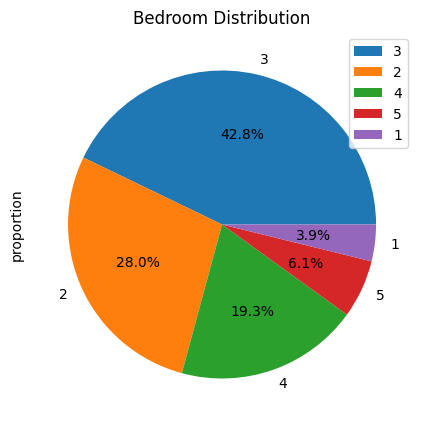

In [42]:
df.bedRoom.value_counts(normalize = True).head(5).plot(kind = 'pie', autopct='%1.1f%%', figsize = (10,5), title = "Bedroom Distribution", legend = True)

# READ: bedRoom — 2/3/4 BHK dominate. Very high bedroom counts (tiny freq) are suspect data-entry errors.


# Bathroom

In [43]:
df.bathroom.value_counts()

bathroom
2     1157
3     1151
4      864
5      306
1      177
6      124
7       44
9       42
8       28
12      22
10      11
16       8
18       4
11       4
13       4
17       3
20       3
14       2
21       1
36       1
34       1
Name: count, dtype: int64

In [44]:
df.bathroom.isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

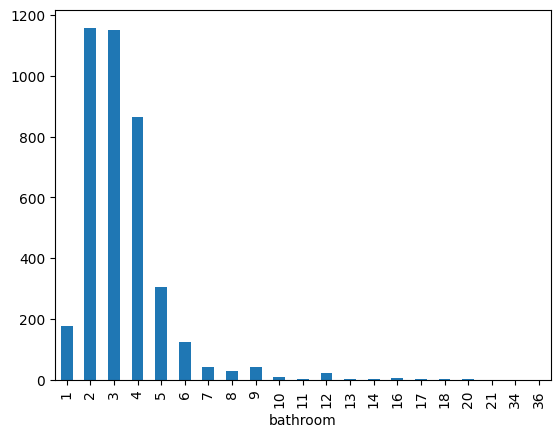

In [45]:
df.bathroom.value_counts().sort_index().plot(kind = 'bar')

<Axes: ylabel='proportion'>

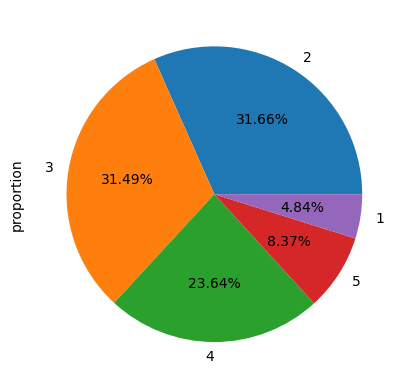

In [46]:
df.bathroom.value_counts(normalize = True).head().plot(kind = 'pie', autopct = '%0.2f%%')

# READ: bathroom — tracks bedrooms closely. Note for multicollinearity at modelling time.


In [47]:
df.balcony.value_counts()

balcony
3+    1227
3     1131
2      967
1      420
0      212
Name: count, dtype: int64

<Axes: xlabel='balcony'>

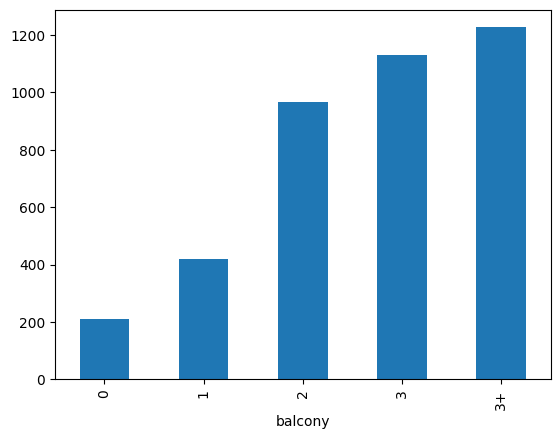

In [48]:
df.balcony.value_counts().sort_index().plot(kind = 'bar')

<Axes: ylabel='proportion'>

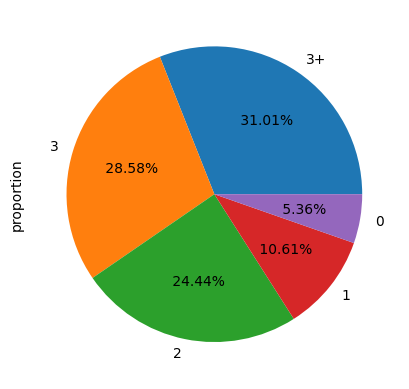

In [49]:
df.balcony.value_counts(normalize = True).plot(kind = 'pie', autopct = '% 0.2f%%')

# READ: balcony — concentrated on low counts; treat as categorical (incl. '3+'/'No' style level).


# FLoor_num


In [50]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,NaN,900.0,NaN,0,0,0,0,0,2,28
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,NaN,650.0,NaN,0,0,0,0,0,0,37
2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,NaN,595.0,NaN,0,0,0,0,0,2,36
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,NaN,1200.0,NaN,1,0,0,0,0,2,76
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,1345.0,NaN,NaN,1,0,0,0,0,2,0


In [51]:
df.floorNum.isnull().sum()

np.int64(24)

<Axes: title={'center': 'Floor Number Distribution'}, xlabel='floorNum'>

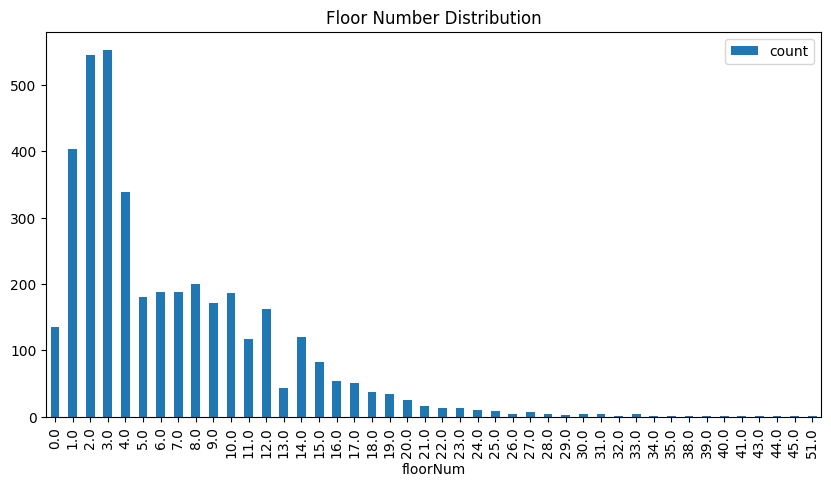

In [52]:
df.floorNum.value_counts().sort_index().plot(kind = 'bar', figsize = (10,5), title = "Floor Number Distribution", legend = True)

In [53]:
df[df.floorNum.isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
180,flat,experion heartsong,sector 102,1.08,6150.0,1756.0,Built Up area: 1758 (163.32 sq.m.),3,3,0,...,NaN,NaN,1758.0,0,0,0,0,0,2,0
212,flat,"ganpati apartment 2, laxman vihar phase 1",laxman vihar,0.45,4705.0,956.0,Carpet area: 850 (78.97 sq.m.),2,2,1,...,NaN,850.00000,NaN,0,0,0,0,0,2,46
2076,flat,huda housing board society,sector 52,0.45,9745.0,462.0,Carpet area: 461.77 (42.9 sq.m.),1,1,0,...,NaN,461.77131,NaN,0,0,1,0,0,0,43
2758,flat,independent,sector 78,0.60,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,NaN,1625.0,0,0,0,0,0,2,0
2911,flat,apna enclave,sector 5,0.80,6153.0,1300.0,Super Built up area 1300(120.77 sq.m.)Built Up...,3,3,1,...,1300.0,NaN,1000.0,0,0,0,0,0,2,0
3020,house,vipul tatvam villa,sector 48,8.50,26235.0,3240.0,Plot area 360(301.01 sq.m.),4,4,2,...,NaN,NaN,360.0,0,1,1,1,0,2,88
3048,house,independent,sector 1,5.60,17284.0,3240.0,Plot area 360(301.01 sq.m.),8,6,3+,...,NaN,NaN,360.0,1,1,1,1,0,2,0
3125,house,independent,dlf phase 3,1.45,26852.0,540.0,Plot area 60(50.17 sq.m.),3,3,1,...,NaN,NaN,60.0,0,0,0,0,0,2,9
3174,house,independent,sector 5,1.50,10288.0,1458.0,Plot area 162(135.45 sq.m.)Built Up area: 210 ...,3,3,0,...,NaN,NaN,210.0,0,0,0,0,0,2,0
3192,house,independent,laxman vihar phase 2,4.12,8889.0,4635.0,Plot area 515(430.61 sq.m.),2,1,3+,...,NaN,NaN,515.0,0,0,0,0,0,2,0


In [54]:
df.floorNum.describe()

count    3933.000000
mean        6.672515
std         6.000937
min         0.000000
25%         2.000000
50%         4.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: ylabel='floorNum'>

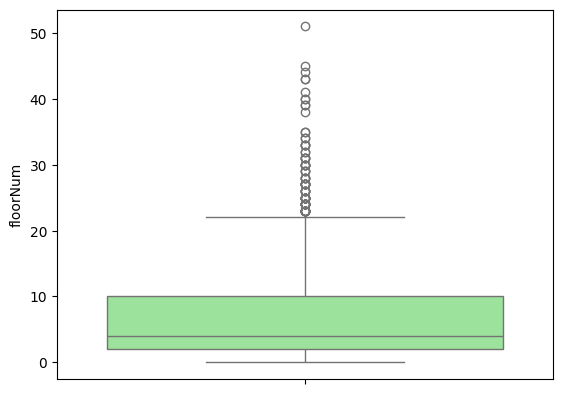

In [55]:
sns.boxplot(df.floorNum,  color = "lightgreen")

# READ: floorNum — concentrated on low/mid floors. Some nulls + extreme highs to verify against real building stock.


In [56]:
df.facing.isnull().sum()

np.int64(1174)

In [57]:
df.facing.fillna("NA", inplace = True)
df.facing.value_counts()

# READ: facing — heavy missingness, filled as explicit 'NA' category. Absence may itself be signal.


C:\Users\Admin\AppData\Local\Temp\ipykernel_27596\2303561002.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.facing.fillna("NA", inplace = True)


facing
NA            1174
East           667
North-East     663
North          410
West           258
South          237
North-West     206
South-East     183
South-West     159
Name: count, dtype: int64

In [58]:
df.agePossession.isnull().sum()

np.int64(0)

In [59]:
df.agePossession.value_counts()

agePossession
Relatively New        1705
New Property           646
Moderately Old         610
Undefined              501
Old Property           353
Under Construction     141
undefined                1
Name: count, dtype: int64

In [60]:
df['agePossession'] = df['agePossession'].replace('undefined', 'Undefined')

In [61]:
df.agePossession.value_counts()

# READ: agePossession — messy labels cleaned ('undefined'→'Undefined'). Mostly ready-to-move vs under-construction tiers.


agePossession
Relatively New        1705
New Property           646
Moderately Old         610
Undefined              502
Old Property           353
Under Construction     141
Name: count, dtype: int64

## Areas

In [62]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,NaN,900.0,NaN,0,0,0,0,0,2,28
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,NaN,650.0,NaN,0,0,0,0,0,0,37


In [63]:
df.super_built_up_area.isnull().sum()

np.int64(2024)

In [64]:
df.super_built_up_area.describe()

count     1933.000000
mean      1918.415641
std        767.891703
min         89.000000
25%       1457.000000
50%       1825.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

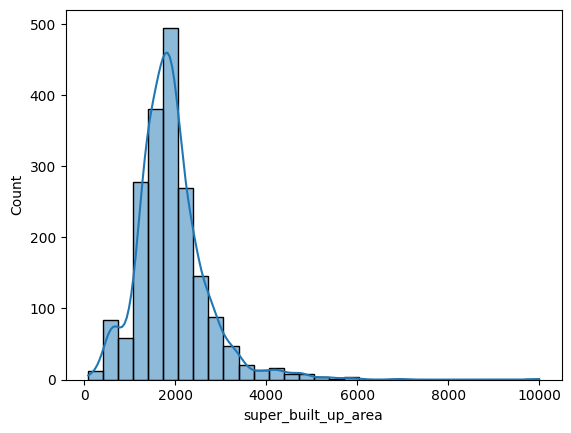

In [65]:
sns.histplot(df.super_built_up_area, bins=30, kde=True)

<Axes: ylabel='super_built_up_area'>

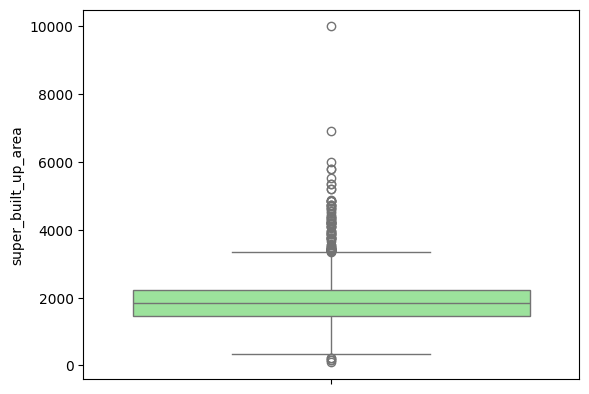

In [66]:
sns.boxplot(df.super_built_up_area, color = 'lightgreen')

# READ: super_built_up_area — right-skewed, heavily missing (rarely co-present with the other area cols).


In [67]:
df.built_up_area.isnull().sum()

np.int64(2100)

In [68]:
df.built_up_area.describe()

count      1857.000000
mean       1791.160891
std       17135.172380
min           2.000000
25%         360.000000
50%        1200.000000
75%        1860.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

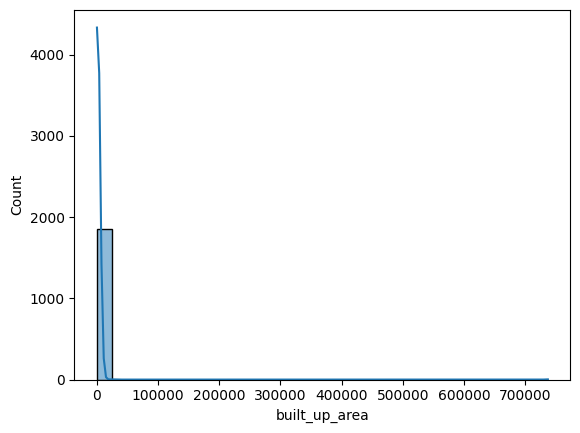

In [69]:
sns.histplot(df.built_up_area, bins=30, kde=True)

<Axes: ylabel='built_up_area'>

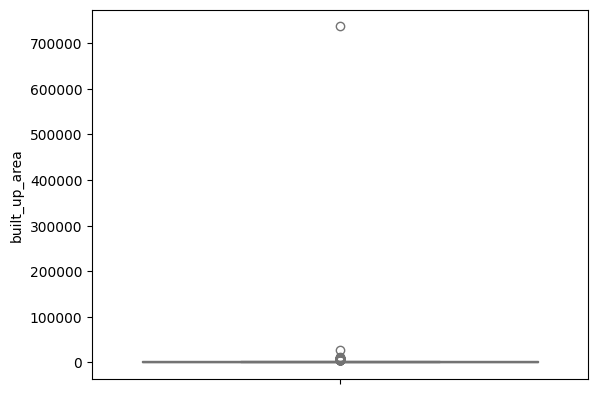

In [70]:
sns.boxplot(df.built_up_area.dropna(), color = 'lightgreen')

Lot more do with this column as extreme outliers detected.

# READ: built_up_area — extreme outliers, largely a side-effect of the earlier Plot_area fill (plot >> built-up). Not real signal.


In [71]:
df.carpet_area.isnull().sum()

np.int64(1956)

In [72]:
df.carpet_area.describe()

count      2001.000000
mean       2445.965971
std       22055.815586
min          15.000000
25%         802.000000
50%        1262.000000
75%        1780.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

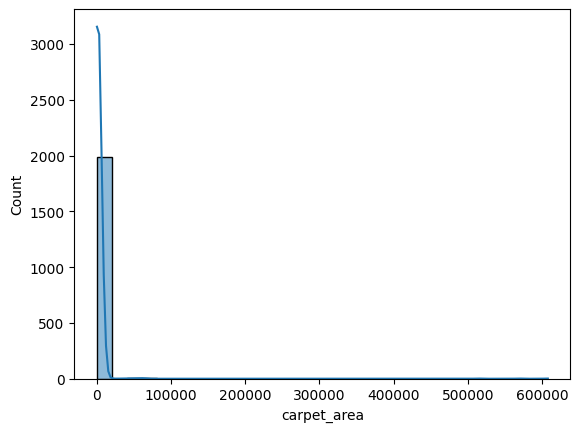

In [73]:
sns.histplot(df.carpet_area, bins=30, kde=True)

<Axes: ylabel='carpet_area'>

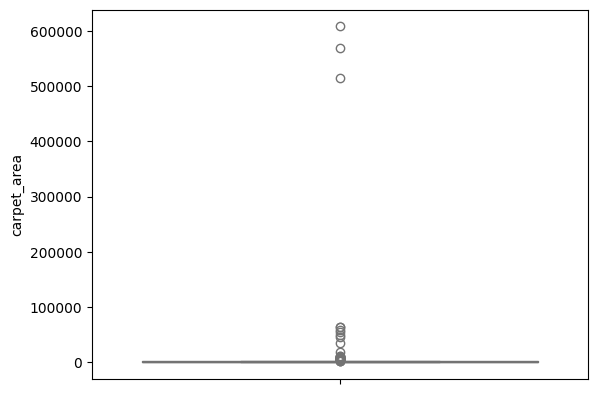

In [74]:
sns.boxplot(df.carpet_area, color = 'lightgreen')

Need to work with the outliers here.

# READ: carpet_area — right-skewed with outliers. Across all 3 area cols: reconcile into ONE feature (collinear + inconsistently populated).


# Additional Rooms.

In [75]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,NaN,900.0,NaN,0,0,0,0,0,2,28
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,NaN,650.0,NaN,0,0,0,0,0,0,37
2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,NaN,595.0,NaN,0,0,0,0,0,2,36
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,NaN,1200.0,NaN,1,0,0,0,0,2,76
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,1345.0,NaN,NaN,1,0,0,0,0,2,0


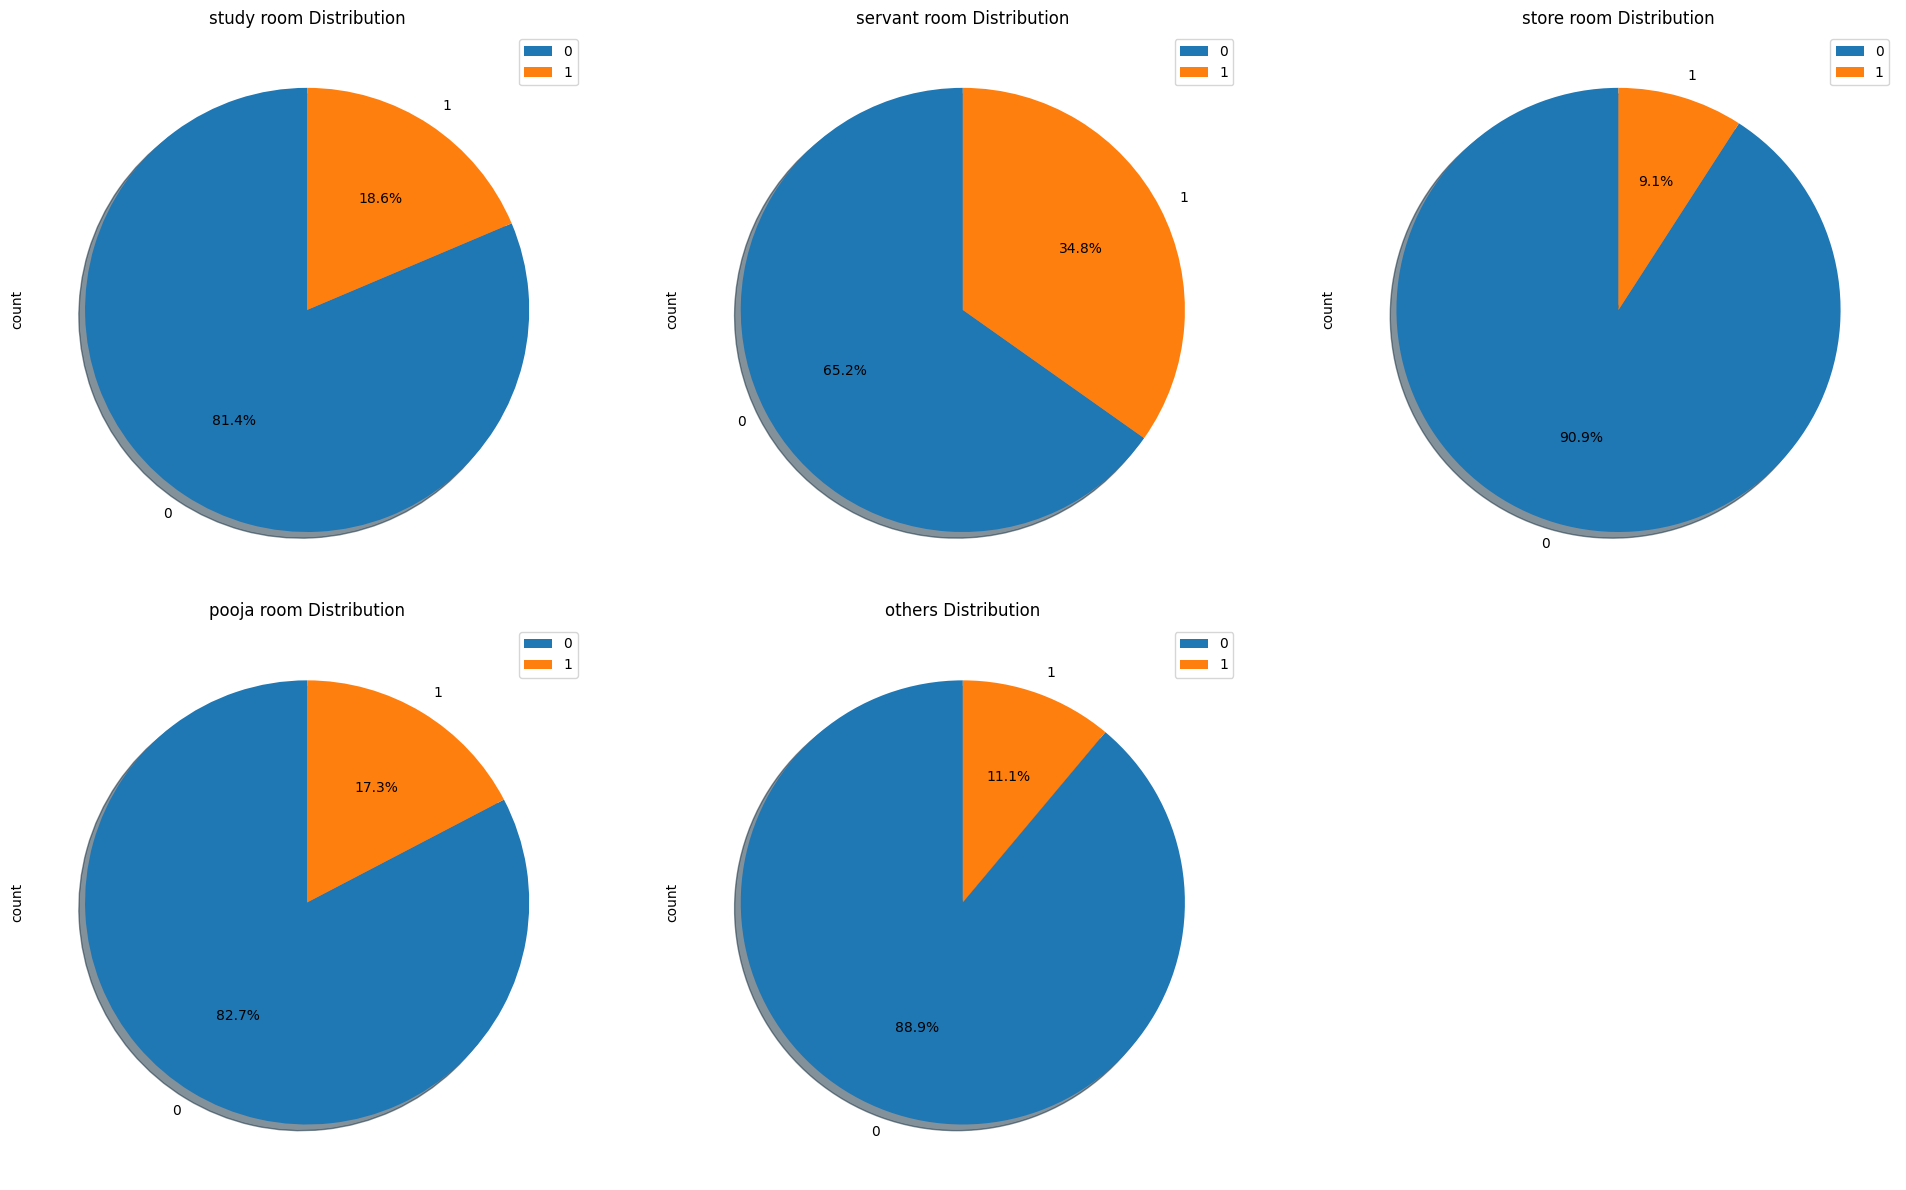

In [76]:
plt.figure(figsize = (20,12))

# creating a subplot for each room type
for idx, room_type in enumerate(['study room', 'servant room', 'store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room_type].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, shadow=True, legend=True, title=f"{room_type} Distribution")

plt.tight_layout()
plt.show()

# READ: extra rooms (study/servant/store/pooja/others) — low-prevalence binary flags. Weak alone; combine into a 'premium amenities' count.


<Axes: title={'center': 'Furnishing Type Distribution'}, xlabel='furnishing_type'>

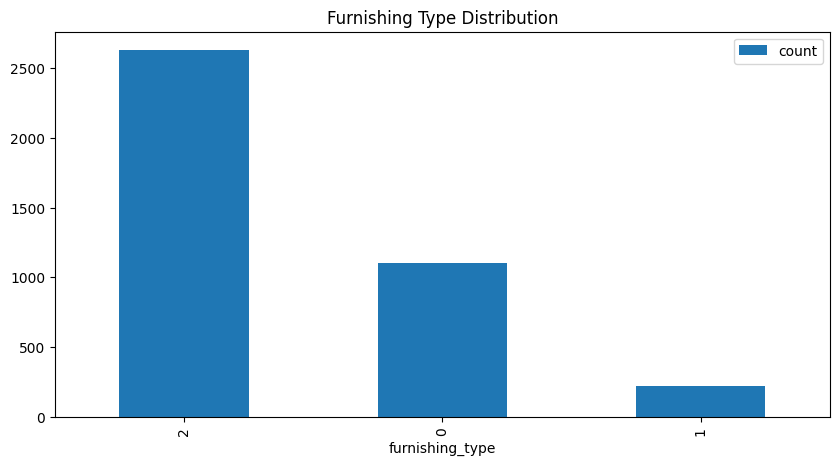

In [77]:
# Furnishing status distribution
df.furnishing_type.value_counts().plot(kind = 'bar', figsize = (10,5), title = "Furnishing Type Distribution", legend = True)

<Axes: title={'center': 'Furnishing Type Distribution'}, ylabel='proportion'>

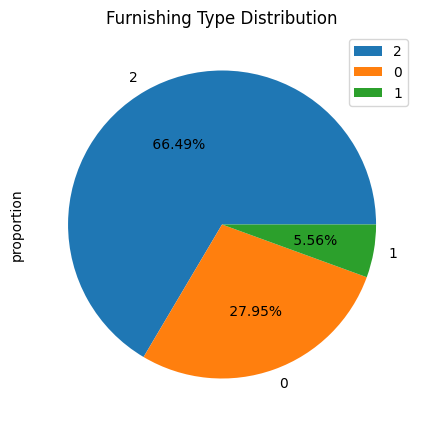

In [78]:
df.furnishing_type.value_counts(normalize = True).plot(kind = 'pie', autopct = '% 0.2f%%', figsize = (10,5), title = "Furnishing Type Distribution", legend = True)

# READ: furnishing_type — unfurnished/semi/fully. Plausible price driver, keep it.


In [79]:
# Luxury status distribution
df.luxury_score.value_counts().sort_index()

luxury_score
0      713
5        6
6        6
7       52
8       34
      ... 
166     11
167     21
168      9
169      1
174    196
Name: count, Length: 160, dtype: int64

In [80]:
df.luxury_score.describe()

count    3957.000000
mean       66.925701
std        54.666306
min         0.000000
25%        21.000000
50%        49.000000
75%       108.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

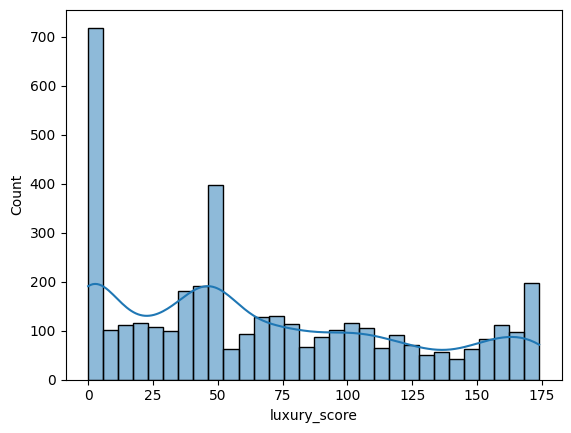

In [81]:
sns.histplot(df.luxury_score, bins=30, kde=True)

<Axes: ylabel='luxury_score'>

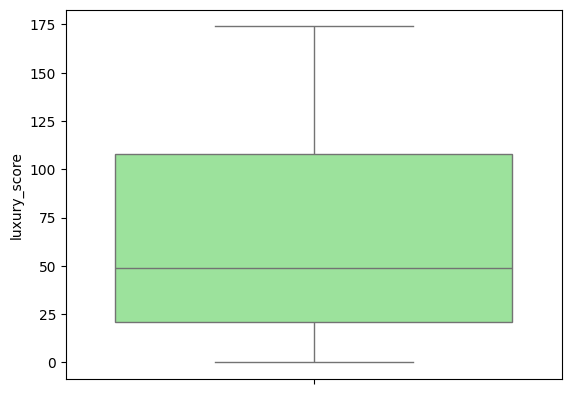

In [82]:
sns.boxplot(df.luxury_score, color = 'lightgreen')

Multimodal


no outliers.

# READ: luxury_score — MULTIMODAL (distinct property tiers), well-bounded, NO true outliers. Consider binning into tiers vs treating as smooth-continuous.
